### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.5", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.5
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.5',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.5/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-c9d77990917f3102ada88be140d28b038d1dd7c7/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.5/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [2]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'
med_path = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging'

Paths = {
        'bloodmnist_x1y3_cs': {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt",
            "inverter_pth": sfe_root + "/experiments/inverter/bloodmnist/fse_inverter_train_002/iteration_100000.pt",
            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y3_Reg_002/iteration_340000.pt"
        },
        'bloodmnist_x1y6_cs': {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt",
            "inverter_pth": sfe_root + "/experiments/inverter/bloodmnist/fse_inverter_train_002/iteration_100000.pt",

            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y6_Reg_000/iteration_340000.pt"
        }
        

        }


change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


model_name = 'bloodmnist_x1y6_cs'
data_name = 'bloodmnist_x1y6'

sfe_ckpt_path = Paths[model_name]["sfe_path"]

# Load config.yaml
config_yaml_path = os.path.join(os.path.dirname(sfe_ckpt_path), "config.yaml")
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)

config.model.w_space_encoder = "pSp"
config.model.checkpoint_path = sfe_ckpt_path
# config.model.pSp_cs_path = Paths[model_name]["pSp_cs_path"]
config.model.pSp_path = Paths[model_name]["pSp_path"]
config.model.batch_size = 4  # Set batch size for inference

config.model.channel_multiplier = 1
config.data.dataset = data_name

# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train_new/bloodmnist/bloodmnist_x1y6_Reg
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: ffhq_glasses
data:
  data_dir: ???
  dataset: bloodmnist_x1y6
  transform: face_256
  special_idx: -1
train:
  train_runner: fse_editor_cs
  inverter_optimizer: ranger
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 2000
  checkpoint_step: 10000
  val_step: 2000
  train_dis: true
  train_disc_edit: false
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
model:
  method: fse_full
  device: '0'
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/yuhe/Proj

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device

sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 26.59 GB / 40.00 GB

Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 1
[DEBUG----------------------------] stylegan_size = 256
n_styles:  14
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/bloodmnist_Ros/checkpoints/iteration_460000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bloodmnist/bloodmnist_x1y6_Reg/checkpoints/iteration_80000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/pretrained_medminist/bloodmnist-009676_fid11.7079.pkl
✅ pkl loaded via legacy_load
✅ load_disc_any(module->ada): loaded all 64 keys (no mismatch).
✅ discriminator loaded from MODULE (re-instantiated RGB)
Loading refined-

In [ ]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# ============================================================
# 0) Import your interp_utils
#    (把 UTILS_PARENT 改成 interp_utils 文件夹所在的父目录)
# ============================================================
UTILS_PARENT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN").resolve()
if str(UTILS_PARENT) not in sys.path:
    sys.path.insert(0, str(UTILS_PARENT))

from interp_utils import (
    load_timm_binary_classifier,
    load_fastdime_classifier,
    score_alpha_series,
)

# ============================================================
# 1) Load classifier (CHOOSE ONE)
# ============================================================

# ---- Switch here ----
CLS_BACKEND = "timm"      # "timm" or "fastdime"
PNG_LIKE   = False        # timm only: False=tensor-direct, True=png-like quant
T_VAL      = 0            # fastdime needs t; timm ignores it

if CLS_BACKEND == "timm":
    data_name  = "bratsHT_new"
    model_type = "densenet121"  # densenet121 / resnet34 / swinv2_large / swinv2_small
    ckpt_pth   = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/evaluation/image_classification/{data_name}/{model_type}/best_model.pth"

    cls = load_timm_binary_classifier(ckpt_pth, model_type=model_type, img_size=256)
    device = cls.device
    print(f"✅ timm classifier loaded: {model_type} | device={device} | PNG_LIKE={PNG_LIKE}")

elif CLS_BACKEND == "fastdime":
    # 如果你还是想用原来的 fastdime 这套，就在这里填 ckpt/type
    # 你也可以继续用你原来的 load_our_classifier，但这里统一成 interp_utils 的 loader
    cls_type = "densenet"  # "unet_encoder" / "resnet" / "densenet"
    ckpt_map = {
        "unet_encoder": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt",
        "resnet":       "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt",
        "densenet":     "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt",
    }
    cls_ckpt = ckpt_map[cls_type]

    cls = load_fastdime_classifier(cls_ckpt=cls_ckpt, cls_type=cls_type)
    device = cls.device
    print(f"✅ fastdime classifier loaded: {cls_type} | device={device}")

else:
    raise ValueError("CLS_BACKEND must be 'timm' or 'fastdime'")

# ============================================================
# 2) Seed + data paths
#    (get_random_seeds / configure_Seg_datasets / sfe_model 都假设你已经在 notebook 里定义好了)
# ============================================================

seed = get_random_seeds()
print("seed:", seed)
# seed = 4175
bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
t_path  = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_Y.npy"

test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(
    sfe_model.config, seed=seed, shuffle=True, bg_path=bg_path, t_path=t_path
)

# ============================================================
# 3) Alpha range
# ============================================================
num_steps = 11

# alphas_x = torch.linspace(0, 1, steps=num_steps, device=device)
# alphas_y = alphas_x.clone()
alphas_x = torch.tensor([0.3, 0.4, 0.5, 0.6, 0.7, 0.8], device=device)
alphas_y = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], device=device)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x.detach().cpu()]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y.detach().cpu()]

# ============================================================
# 4) Utils: infinite target loader
# ============================================================
def infinite_loader(dataloader):
    while True:
        for batch in dataloader:
            yield batch

t_iter = infinite_loader(test_t_dataloader)

# ============================================================
# 5) Save one visual sample only
# ============================================================
VIS_GLOBAL_INDEX = 0
vis_recon_X_alpha = None  # list of [1,C,256,256]
vis_recon_Y_alpha = None
vis_probs_x = None        # [num_steps+1]
vis_probs_y = None

# ============================================================
# 6) Run interpolation scoring (X2Y / Y2X)
# ============================================================
all_probs_x2y = []
all_probs_y2x = []

global_idx = 0

# 你之前写了 classifier.eval()；现在 cls 是 bundle，用 cls.model.eval()
with torch.inference_mode():
    sfe_model.method.train()     # 你之前说 pipeline 可能要求 train mode
    cls.model.eval()

    for batch_idx, batch_bg in tqdm(enumerate(test_bg_dataloader), total=len(test_bg_dataloader)):
        X = batch_bg.to(device).float()
        Y = next(t_iter).to(device).float()

        # ---- align Y batch size to X ----
        Bx, By = X.size(0), Y.size(0)
        if By < Bx:
            reps = (Bx + By - 1) // By
            Y = Y.repeat(reps, 1, 1, 1)[:Bx]
        else:
            Y = Y[:Bx]

        # resize
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

        # latents
        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

        # deltas
        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

        # whether this batch contains the global vis index
        need_vis_in_this_batch = (VIS_GLOBAL_INDEX >= global_idx) and (VIS_GLOBAL_INDEX < global_idx + Bx)
        local_i = (VIS_GLOBAL_INDEX - global_idx) if need_vis_in_this_batch else None

        # ---- score alpha series with unified API ----
        probs_x2y_t, vis_x = score_alpha_series(
            base_imgs=X_resh,
            delta=delta_x2y,
            alphas=alphas_x,
            recon_by_delta_fn=recon_by_delta,
            classifier=cls,
            t_val=T_VAL,
            png_like=PNG_LIKE,
            keep_index_in_batch=local_i,
            recon_kwargs=dict(sfe_model=sfe_model),
        )

        probs_y2x_t, vis_y = score_alpha_series(
            base_imgs=Y_resh,
            delta=delta_y2x,
            alphas=alphas_y,
            recon_by_delta_fn=recon_by_delta,
            classifier=cls,
            t_val=T_VAL,
            png_like=PNG_LIKE,
            keep_index_in_batch=local_i,
            recon_kwargs=dict(sfe_model=sfe_model),
        )

        probs_x_batch = probs_x2y_t.detach().cpu().numpy()  # [B, num_steps+1]
        probs_y_batch = probs_y2x_t.detach().cpu().numpy()

        all_probs_x2y.append(probs_x_batch)
        all_probs_y2x.append(probs_y_batch)

        if need_vis_in_this_batch:
            vis_recon_X_alpha = vis_x
            vis_recon_Y_alpha = vis_y
            vis_probs_x = probs_x_batch[local_i].copy()
            vis_probs_y = probs_y_batch[local_i].copy()

        global_idx += Bx

        # DEBUG: 只跑一个 batch 就 break（你原来就有）
        break

all_probs_x2y = np.concatenate(all_probs_x2y, axis=0)
all_probs_y2x = np.concatenate(all_probs_y2x, axis=0)

print("✅ all_probs_x2y:", all_probs_x2y.shape)
print("✅ all_probs_y2x:", all_probs_y2x.shape)

# ============================================================
# 7) Visualization helpers
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)
    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
        0.02, 0.10, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

# crop config（跟你原来一致）
h = 5
crop_cfg = dict(w_l=30 + h, w_r=30 - h, h_top=30, h_bot=30)
%matplotlib inline
# --- single sample visualization ---
if vis_recon_X_alpha is not None and vis_probs_x is not None:
    num_images = len(vis_recon_X_alpha)
    col_spacing = 0.0
    total_width = 1.0
    img_width = (total_width - (num_images - 1) * col_spacing) / num_images
    title_height = 0.10

    # X row
    fig_x = plt.figure(figsize=(num_images * 2.2, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(vis_recon_X_alpha[i][0], crop_cfg)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(titles_x[i], fontsize=18, pad=2)
        add_prob_overlay(ax, vis_probs_x[i], fontsize=14)
    plt.show()

    # Y row
    fig_y = plt.figure(figsize=(num_images * 2.2, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig_y.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(vis_recon_Y_alpha[i][0], crop_cfg)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(titles_y[i], fontsize=18, pad=2)
        add_prob_overlay(ax, vis_probs_y[i], fontsize=14)
    plt.show()

    # curves
    x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
    y_axis = np.concatenate(([-0.05], alphas_y.detach().cpu().numpy()))

    plt.figure(figsize=(6,4))
    plt.plot(x_axis, vis_probs_x, marker="o")
    plt.ylim(0, 1)
    plt.xlabel("alpha (real at -0.05)")
    plt.ylabel("P(tumor)")
    plt.title(f"Sample #{VIS_GLOBAL_INDEX}: X→Y interpolation ({CLS_BACKEND}, png_like={PNG_LIKE})")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(y_axis, vis_probs_y, marker="o")
    plt.ylim(0, 1)
    plt.xlabel("alpha (real at -0.05)")
    plt.ylabel("P(tumor)")
    plt.title(f"Sample #{VIS_GLOBAL_INDEX}: Y→X interpolation ({CLS_BACKEND}, png_like={PNG_LIKE})")
    plt.grid(True)
    plt.show()

# --- mean curves (optional) ---
# mean_x = all_probs_x2y.mean(axis=0)
# mean_y = all_probs_y2x.mean(axis=0)
# x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
# plt.figure(figsize=(6,4))
# plt.plot(x_axis, mean_x, marker="o")
# plt.ylim(0, 1)
# plt.xlabel("alpha (real at -0.05)")
# plt.ylabel("P(tumor)")
# plt.title(f"MEAN over all bg: X→Y ({CLS_BACKEND}, png_like={PNG_LIKE})")
# plt.grid(True)
# plt.show()
#
# plt.figure(figsize=(6,4))
# plt.plot(x_axis, mean_y, marker="o")
# plt.ylim(0, 1)
# plt.xlabel("alpha (real at -0.05)")
# plt.ylabel("P(tumor)")
# plt.title(f"MEAN over all bg: Y→X ({CLS_BACKEND}, png_like={PNG_LIKE})")
# plt.grid(True)
# plt.show()

# 11962  1352 10166 16903 

# 2315 6339

## Image qualitative evaluation

Random seed: 16125
Loading dataset
Using dataset: bloodmnist_x1y6


  0%|          | 0/117 [00:01<?, ?it/s]


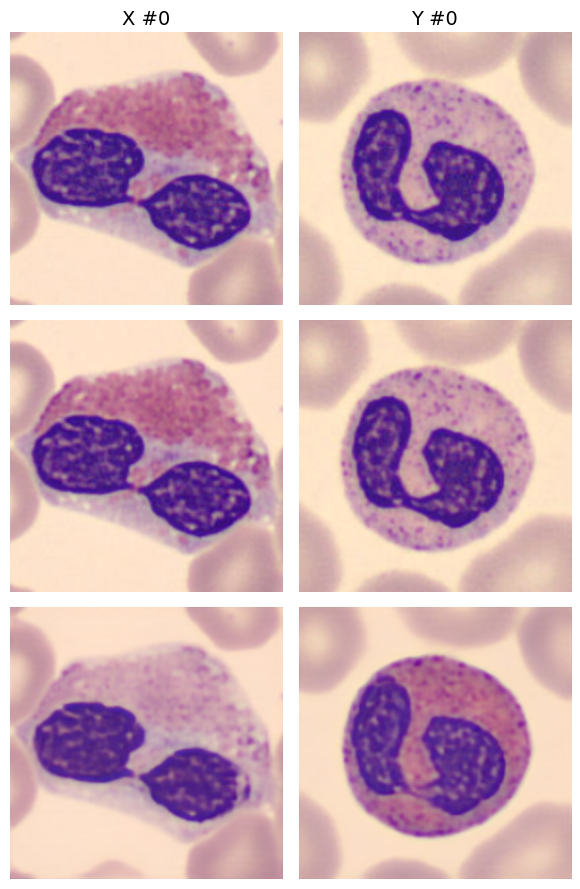

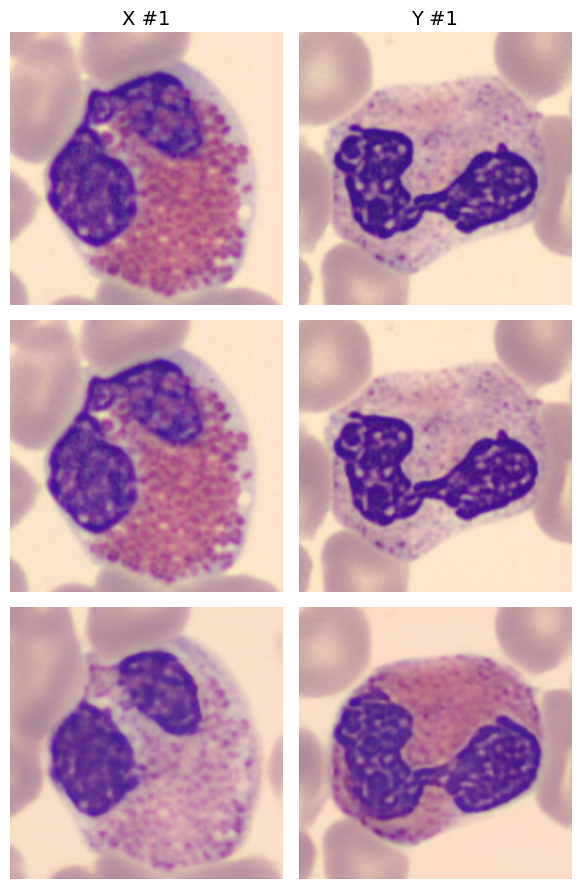

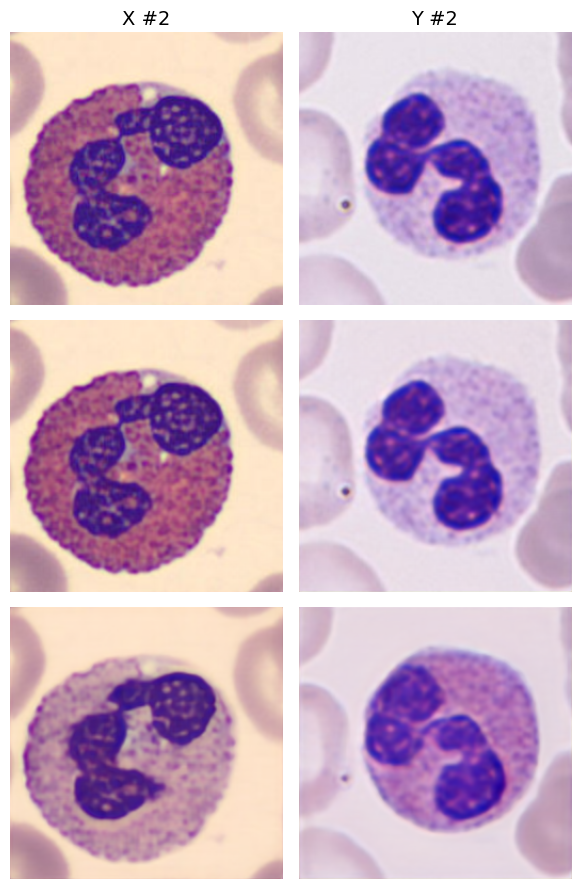

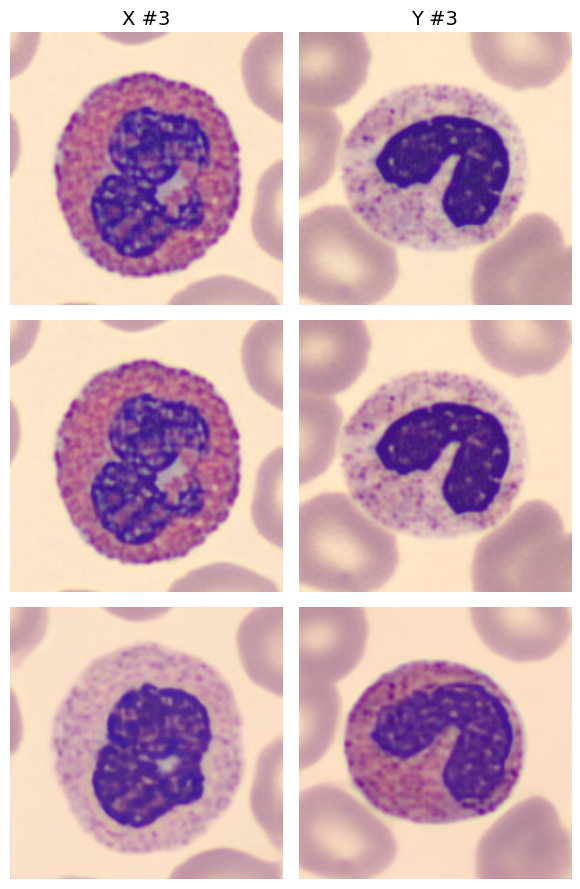

In [6]:
seed = get_random_seeds()
#seed = 18743 17786
# === Get data ===
# sfe_model.config.data.dataset = 'bloodmnist'

test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True)


%matplotlib inline
inference(sfe_model, test_bg_dataloader, test_t_dataloader, idx=0, vis_mode="col", num_pairs=4)



# Image quantitative evaluation

In [7]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===

ds_name = sfe_model.config.data.dataset
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name =ds_name)

exp_name = f"Ours_bloodmnist/{sfe_model.config.train.train_runner}/images/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"



max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

image_paths = ['real_X', 'real_Y', 'recon_w_X', 'recon_w_Y', 'swap_w_Y2X', 'swap_w_X2Y', 'recon_f_X', 'recon_f_Y', 'swap_f_X2Y', 'swap_f_Y2X']

for path in image_paths:
    dir_path = os.path.join(save_image_dir, path)
    os.makedirs(dir_path)


with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
        s_x = torch.zeros_like(s_x)
        recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
        recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

        swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
        swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

        recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
        recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
        swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)


        # collect (keys align with image_paths)
        images = {
            "real_X": X,
            "real_Y": Y,
            "recon_w_X": recon_w_X,
            "recon_w_Y": recon_w_Y,
            "recon_f_X": recon_f_X,
            "recon_f_Y": recon_f_Y,
            "swap_w_X2Y": swap_w_X2Y,
            "swap_w_Y2X": swap_w_Y2X,
            "swap_f_X2Y": swap_f_X2Y,
            "swap_f_Y2X": swap_f_Y2X,
        }



        # de-normalize / postprocess per tensor (skip None)
        images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}

        # save all groups
        B = next(v.size(0) for v in images.values() if v is not None)
        for i in range(B):
            idx = batch_idx * B + i
            for key, tensor in images.items():
                if tensor is None or tensor.ndim != 4 or i >= tensor.size(0):
                    continue
                img_i = tensor[i].detach().cpu().clamp(0, 1)  # safety clamp
                save_image(img_i, os.path.join(save_image_dir, key, f"{idx}.png"))

    print(f"Results images saved to {save_image_dir}")

Random seed: 11095
Loading dataset
Using dataset: bloodmnist_x1y6


100%|██████████| 117/117 [04:17<00:00,  2.20s/it]

Results images saved to /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Ours_bloodmnist/fse_editor_cs/images/bloodmnist_x1y6_Reg


## Latent separation evaluation

In [8]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===
ds_name = config.data.dataset #= 'bloodmnist_x1y6'
model_name = ds_name
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name=ds_name)
# test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False)
exp_name = f"Ours_bloodmnist/{sfe_model.config.train.train_runner}/latents/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"


max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

# Prepare directories for saving images
latent_paths = ['latents_x', 'latents_y']

for path in latent_paths:
    dir_path = os.path.join(save_image_dir, path)
    if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
    os.makedirs(dir_path)


sfe_model.method.train()
with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

        # Group latents for background (x) and target (y)
        latents = {
            "x": {"c": c_x, "s": s_x},
            "y": {"c": c_y, "s": s_y},
        }        

        # Save latents per sample
        batch_size = X.size(0)
        for i in range(batch_size):
            idx = batch_idx * batch_size + i
            for key in ["x", "y"]:
                save_path = os.path.join(save_image_dir, f"latents_{key}", f"latent_{key}_{idx}.pt")
                torch.save({k: v[i].cpu() for k, v in latents[key].items()}, save_path)


Random seed: 10442
Loading dataset
Using dataset: bloodmnist_x1y6


100%|██████████| 117/117 [00:18<00:00,  6.30it/s]


## Interpolation

Random seed: 3594
Loading dataset
Using dataset: bloodmnist_x1y3


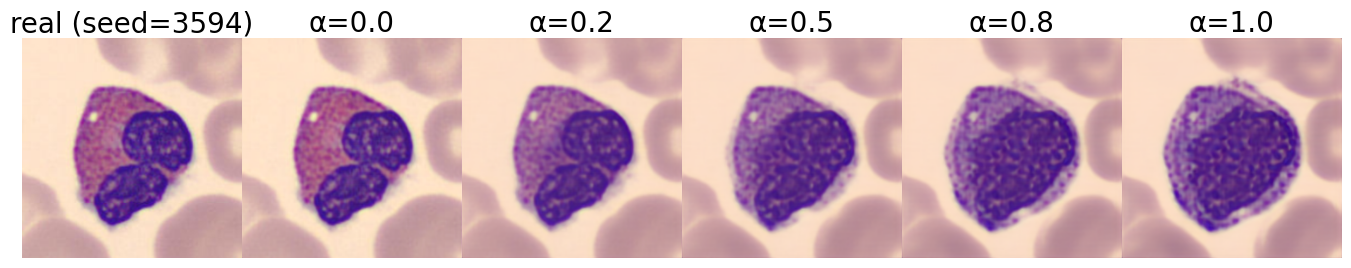

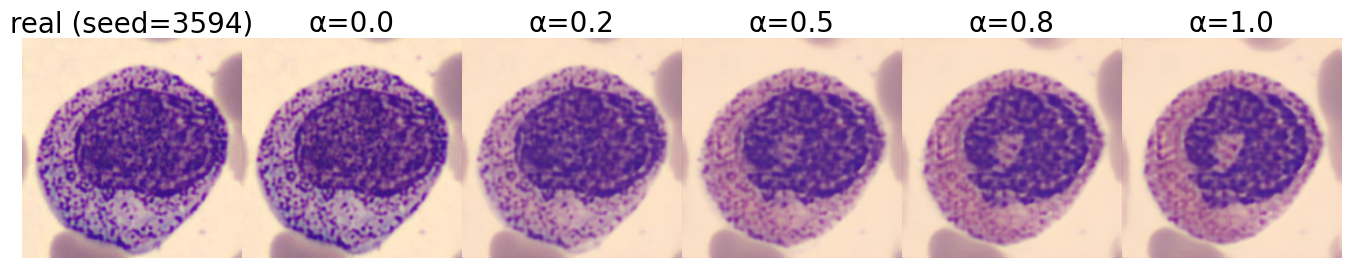

In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# =========================
# Seed & Data
# =========================
seed = get_random_seeds()
# seed = 13477

test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))

# =========================
# Alpha Range
# =========================
alphas_x = torch.linspace(0, 1, steps=5)
alphas_y = torch.linspace(0, 1, steps=5)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]

# =========================
# Prepare Reconstructions
# =========================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    # ===== latents =====
    c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(
        X_resh, Y_resh, sfe_model
    )

    # ===== add REAL images first =====
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    # ===== deltas =====
    delta_x2y = calculate_delta_by_latent(
        c_x + s_x1 + s_x2,
        c_x + s_y1 + s_y2,
        sfe_model
    )

    delta_y2x = calculate_delta_by_latent(
        c_y + s_y1 + s_y2,
        c_y + s_x1 + s_x2,
        sfe_model
    )

    # ===== alpha interpolation =====
    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(
            X_resh, alpha_x * delta_x2y, sfe_model=sfe_model
        )
        swap_f_Y2X = recon_by_delta(
            Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model
        )

        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

# =========================
# Crop Utils
# =========================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

# =========================
# Crop Config
# =========================
h = 0
dist = 0
crop_cfg = dict(
    w_l=dist + h,
    w_r=dist - h,
    h_top=dist,
    h_bot=dist
)

# =========================
# Visualization
# =========================
num_images = len(recon_X_alpha)   # == len(titles_x)
col_spacing = 0.0
title_height = 0.05
total_width = 1.0
img_width = (total_width - (num_images - 1) * col_spacing) / num_images

%matplotlib inline

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_x[i], fontsize=20, pad=2)

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_y[i], fontsize=20, pad=2)

plt.show()
